In [1]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")

In [2]:
# Set or create an experiment
mlflow.set_experiment("Exp 5 - ML Algos with HP Tuning")

c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/18 00:31:24 INFO mlflow.tracking.fluent: Experiment with name 'Exp 5 - ML Algos with HP Tuning' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:c:/Users/Soham/Documents/youtube comment '
 'analyzer/mlruns/828082313912743457'), creation_time=1779044484201, experiment_id='828082313912743457', last_update_time=1779044484201, lifecycle_stage='active', name='Exp 5 - ML Algos with HP Tuning', tags={}, trace_location=None, workspace='default'>

[I 2026-05-18 00:36:43,312] A new study created in memory with name: no-name-a16699ff-64dc-41bf-942a-af7201ae1de0


CLASSES:
[1 2 0]

CLASS COUNTS:

category
1    15770
0    12644
2     8248
Name: count, dtype: int64


[I 2026-05-18 00:39:35,355] Trial 0 finished with value: 0.6521306011881078 and parameters: {'n_estimators': 180, 'learning_rate': 0.023524144719576184, 'max_depth': 7, 'subsample': 0.7268068626518848, 'colsample_bytree': 0.9416409918061237, 'min_child_weight': 8, 'gamma': 2.1322779312679896, 'reg_alpha': 1.67714846888797, 'reg_lambda': 2.1002161034613716}. Best is trial 0 with value: 0.6521306011881078.
[I 2026-05-18 00:41:30,880] Trial 1 finished with value: 0.6821637647329486 and parameters: {'n_estimators': 263, 'learning_rate': 0.03854941425085535, 'max_depth': 5, 'subsample': 0.9712082166706126, 'colsample_bytree': 0.9121865745527046, 'min_child_weight': 4, 'gamma': 4.283424241612118, 'reg_alpha': 4.9036707468013, 'reg_lambda': 2.810562958119405}. Best is trial 1 with value: 0.6821637647329486.
[I 2026-05-18 00:43:35,105] Trial 2 finished with value: 0.6200341390763535 and parameters: {'n_estimators': 183, 'learning_rate': 0.01200800386411029, 'max_depth': 8, 'subsample': 0.76126

BEST PARAMETERS
{'n_estimators': 361, 'learning_rate': 0.1555146980038642, 'max_depth': 6, 'subsample': 0.9971741338740573, 'colsample_bytree': 0.7001314765716844, 'min_child_weight': 2, 'gamma': 0.3010687003584987, 'reg_alpha': 0.868108071168384, 'reg_lambda': 0.028554261762137552}

Accuracy    : 0.8336
Macro F1    : 0.8203
Weighted F1 : 0.8320

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.96      0.87      2529
           1       0.91      0.79      0.85      3154
           2       0.77      0.72      0.74      1650

    accuracy                           0.83      7333
   macro avg       0.83      0.82      0.82      7333
weighted avg       0.84      0.83      0.83      7333



2026/05/18 02:33:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


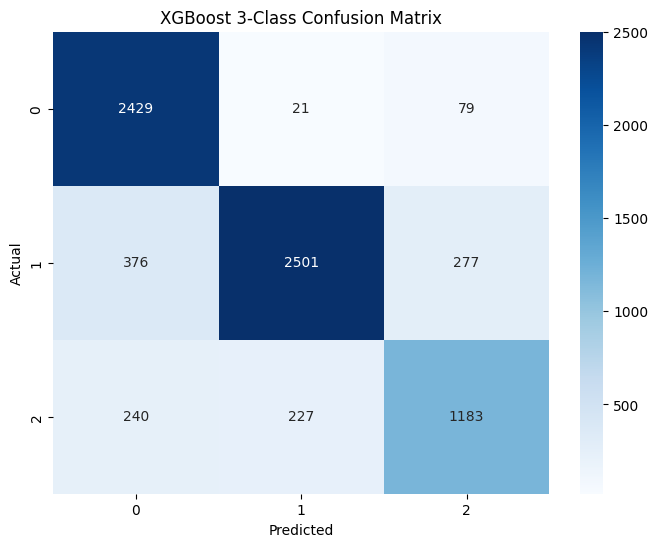

In [3]:
# =========================================================
# IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import optuna
import mlflow

from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import (
    compute_sample_weight
)

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# RANDOM SEED
# =========================================================
np.random.seed(42)

# =========================================================
# LOAD DATASET
# =========================================================
df_original = pd.read_csv(
    "reddit_preprocessing.csv"
).dropna()

# =========================================================
# SAFE COPY
# =========================================================
df = df_original.copy()

# =========================================================
# MAP LABELS
# XGBoost requires 0,1,2 labels
# =========================================================
df['category'] = df['category'].map({

    -1: 2,

    0: 0,

    1: 1
})

# =========================================================
# REMOVE NaN
# =========================================================
df = df.dropna(
    subset=['category']
)

# =========================================================
# VERIFY CLASSES
# =========================================================
print("=" * 60)

print("CLASSES:")

print(df['category'].unique())

print("\nCLASS COUNTS:\n")

print(df['category'].value_counts())

print("=" * 60)

# =========================================================
# FEATURES / TARGET
# =========================================================
X_text = df['clean_comment']

y = df['category']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
X_train_text, X_test_text, y_train, y_test = train_test_split(

    X_text,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

# =========================================================
# SAMPLE WEIGHTS
# =========================================================
sample_weights = compute_sample_weight(

    class_weight='balanced',

    y=y_train
)

# =========================================================
# TF-IDF SETTINGS
# =========================================================
ngram_range = (1, 3)

max_features = 5000

# =========================================================
# CROSS VALIDATION
# =========================================================
cv = StratifiedKFold(

    n_splits=3,

    shuffle=True,

    random_state=42
)



# =========================================================
# OPTUNA OBJECTIVE FUNCTION
# =========================================================
def objective_xgboost(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            400
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.20,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            8
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.7,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.7,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            5
        ),

        # =================================================
        # MULTICLASS SETTINGS
        # =================================================
        "objective": "multi:softmax",

        "num_class": 3,

        "eval_metric": "mlogloss",

        "random_state": 42,

        "n_jobs": 4
    }

    # =====================================================
    # PIPELINE
    # =====================================================
    pipeline = Pipeline([

        (
            "tfidf",

            TfidfVectorizer(

                ngram_range=ngram_range,

                max_features=max_features,

                min_df=3,

                max_df=0.90,

                sublinear_tf=True
            )
        ),

        (
            "model",

            XGBClassifier(
                **params
            )
        )
    ])

    # =====================================================
    # CROSS VALIDATION
    # =====================================================
    scores = cross_val_score(

        pipeline,

        X_train_text,

        y_train,

        cv=cv,

        scoring='f1_macro',

        n_jobs=1
    )

    return np.mean(scores)

# =========================================================
# RUN OPTUNA
# =========================================================
study = optuna.create_study(
    direction="maximize"
)

study.optimize(

    objective_xgboost,

    n_trials=30
)

# =========================================================
# BEST PARAMETERS
# =========================================================
print("=" * 60)

print("BEST PARAMETERS")

print(study.best_params)

print("=" * 60)

# =========================================================
# FINAL TF-IDF
# =========================================================
vectorizer = TfidfVectorizer(

    ngram_range=ngram_range,

    max_features=max_features,

    min_df=3,

    max_df=0.90,

    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(
    X_train_text
)

X_test_vec = vectorizer.transform(
    X_test_text
)

# =========================================================
# FINAL MODEL
# =========================================================
best_model = XGBClassifier(

    **study.best_params,

    objective="multi:softmax",

    num_class=3,

    eval_metric="mlogloss",

    random_state=42,

    n_jobs=4
)

# =========================================================
# TRAIN FINAL MODEL
# =========================================================
best_model.fit(

    X_train_vec,

    y_train,

    sample_weight=sample_weights
)

# =========================================================
# PREDICTIONS
# =========================================================
y_pred = best_model.predict(
    X_test_vec
)

# =========================================================
# METRICS
# =========================================================
accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(

    y_test,

    y_pred,

    average='macro'
)

weighted_f1 = f1_score(

    y_test,

    y_pred,

    average='weighted'
)

# =========================================================
# RESULTS
# =========================================================
print(f"\nAccuracy    : {accuracy:.4f}")

print(f"Macro F1    : {macro_f1:.4f}")

print(f"Weighted F1 : {weighted_f1:.4f}")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================
conf_matrix = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(

    conf_matrix,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=[0,1,2],

    yticklabels=[0,1,2],

    ax=ax
)

ax.set_xlabel("Predicted")

ax.set_ylabel("Actual")

ax.set_title(
    "XGBoost 3-Class Confusion Matrix"
)

# =========================================================
# MLFLOW LOGGING
# =========================================================
with mlflow.start_run(
    run_name="XGBoost_30Trials"
):

    mlflow.set_tag(
        "model",
        "XGBoost"
    )

    mlflow.set_tag(
        "vectorizer",
        "TF-IDF"
    )

    mlflow.log_params(
        study.best_params
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.log_metric(
        "macro_f1",
        macro_f1
    )

    mlflow.log_metric(
        "weighted_f1",
        weighted_f1
    )

    mlflow.log_figure(
        fig,
        "xgboost_confusion_matrix.png"
    )

    mlflow.sklearn.log_model(

        sk_model=best_model,

        name="xgboost_model"
    )

plt.show()

plt.close(fig)